# WFS controls for operation at ALS beamline 5.3.1
walangrizolli@lbl.gov, francisho@lbl.gov, khchan@lbl.gov, awojdyla@lbl.gov

We cleaned up the code, refactoring ophyd classes into nabla.nophyd.
We tried to use the Central tiled server, but somehow we cannot get the data back

We want to: 
+ collect data with various bender settings
+ collect data with various photon energy
+ FrankotChellapize the whole shebang


## Setting up epics/ophyd/bluesky/tiled

## Bender scan at position 13
We think we're on row 5 with 7 um shearing grating

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from tiled.client import from_uri

#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)


In [ ]:
from bluesky.plans import scan
# RE(scan([basler_camera], Obender, -2000, 0, 16))

('bcd61661-8218-4b10-ac2b-e66439c072bc',)

In [2]:
uid = 'bcd61661-8218-4b10-ac2b-e66439c072bc'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
bends_um = db['primary']['bender_um'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

In [3]:
# scaling parameters
## there's binning in the data
px_m = (2.4e-6)/5
grating_freq_cpm = 1/7e-6

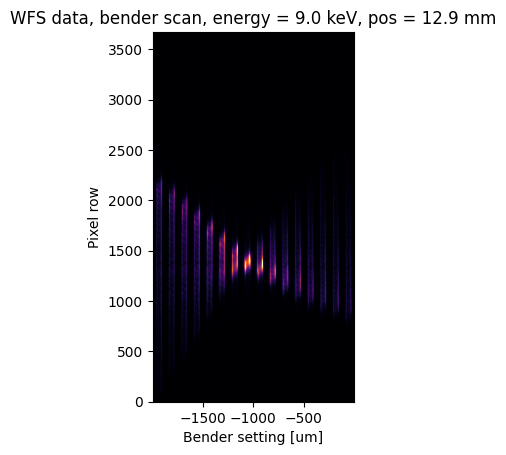

In [4]:
import numpy as np

# Stack the images horizontally
stacked_image = np.hstack(images)

plt.imshow(stacked_image, cmap='inferno',extent=(bends_um[0], bends_um[-1], 0, stacked_image.shape[0]), origin='upper')
plt.title('Horizontally Stacked Images')
plt.title('WFS data, bender scan, energy = %1.1f keV, pos = %.1f mm' % (E_eV[0]*1e-3, wfs_chip_pos_mm[0]))
plt.xlabel('Bender setting [um]')
plt.ylabel('Pixel row')
plt.show()

## Analysis

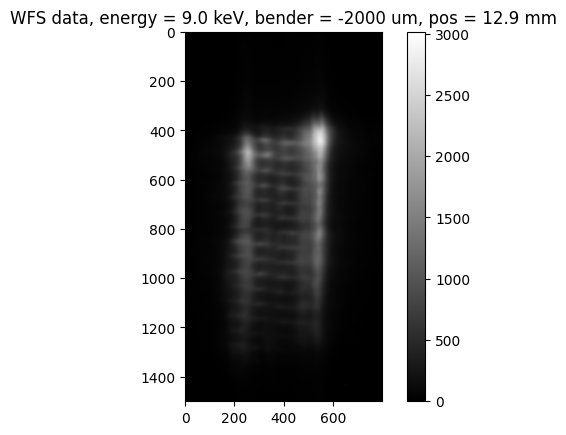

In [160]:
plt.figure()
plt.imshow(images[4,1500:3000], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (E_eV[0]*1e-3, bends_um[0], wfs_chip_pos_mm[0]))
plt.colorbar()
plt.show()


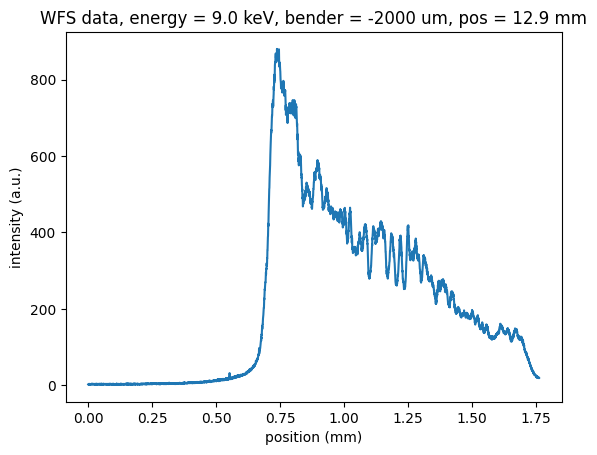

In [157]:
plt.figure()
i = 0
line_avg = images[i,:,500:505].mean(axis=1)
x_m = np.arange(line_avg.shape[0])*px_m
plt.plot(x_m*1e3, line_avg)
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (E_eV[0]*1e-3, bends_um[i], wfs_chip_pos_mm[0]))
plt.xlabel('position (mm)')
plt.ylabel('intensity (a.u.)')
plt.show()

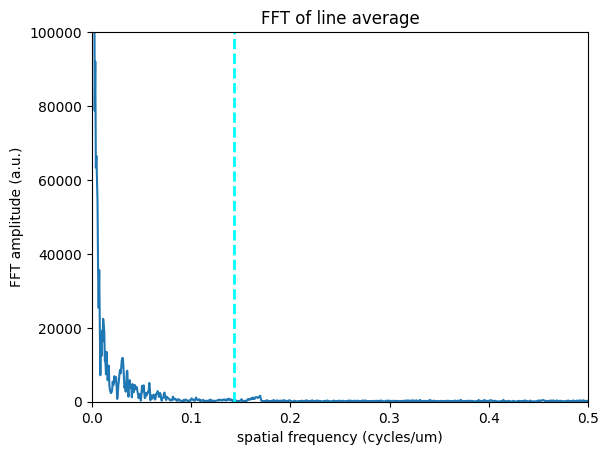

In [158]:
import numpy as np
f_cpm = np.fft.fftshift(np.fft.fftfreq(line_avg.size, d=px_m))
IMG = np.abs(np.fft.fftshift(np.fft.fft(line_avg )))
plt.plot(f_cpm*1e-6, np.abs(IMG))
plt.axvline(grating_freq_cpm * 1e-6, color='cyan', linestyle='--', linewidth=2, label='7um pitch')
plt.xlabel('spatial frequency (cycles/um)')
plt.ylabel('FFT amplitude (a.u.)')
plt.title('FFT of line average')
plt.xlim([0,0.5])
plt.ylim([0,1e5])
plt.show()  

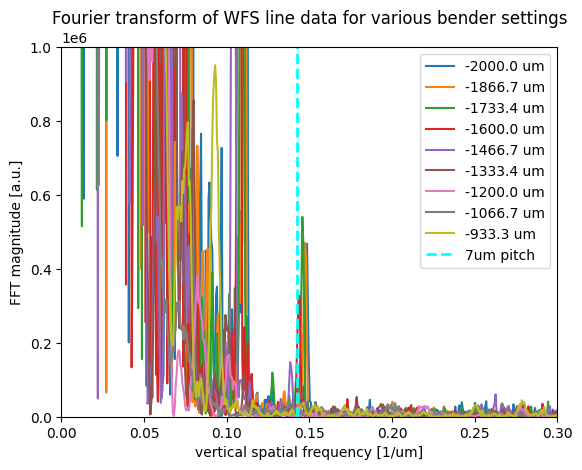

In [89]:
for i_p in range(9):
    line = images[i_p,:,200:220].mean(axis=1)
    line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
    freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))
    plt.plot(freq_y_cpm*1e-6, np.abs(line_FFT)**2, label=f'{bends_um[i_p]:.1f} um')
plt.xlabel('vertical spatial frequency [1/um]')
plt.ylabel('FFT magnitude [a.u.]')
plt.title('Fourier transform of WFS line data for various bender settings')
plt.xlim((0, 0.3))
plt.ylim((0, 1e6))

plt.axvline(grating_freq_cpm * 1e-6, color='cyan', linestyle='--', linewidth=2, label='7um pitch')
plt.legend()
plt.show()

In [90]:
grating_pitch_m = 7e-6
grating_freq_cpm = 1/grating_pitch_m
photon_energy_eV = 9000
wavelength_m = 1234e-9/photon_energy_eV
z_to_grating_m = 300e-3                         # Source to grating [m]
z_T_m = grating_pitch_m**2 / wavelength_m       # Talbot distance (grating to detector) [m]
y_m = np.arange(3672) * px_m

In [91]:
from scipy.signal import find_peaks

# Transform intensity pattern to frequency domain
I_fft = line_FFT

# Create frequency array
freq = freq_y_cpm
M = len(freq)
df = freq[1]-freq[0]  # Frequency resolution [1/m]

mask = (freq > 0.10e6) & (freq < 0.15e6)

# Find peaks in FFT spectrum (use magnitude)
I_fft_magnitude = np.abs(I_fft)
peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

# Identify carrier frequency (should be at ±1/pitch)
#carrier_freq_ideal = 1 / grating_pitch_m
carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - grating_freq_cpm))]
#carrier_idx = np.argmax(I_fft_magnitude*mask)
carrier_freq_measured = freq[carrier_idx]


In [92]:
print(carrier_freq_measured)

142973.85620915034


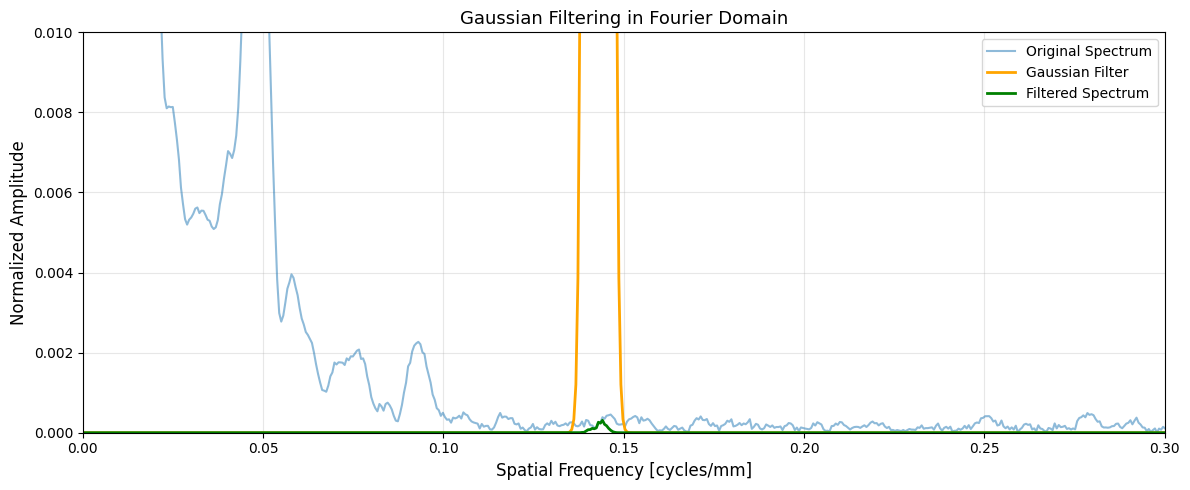

In [93]:
# Create Gaussian filter centered on +1 order
filter_width = 3.0  # pixels (standard deviation)
x_indices = np.arange(M)
gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

# Apply filter to FFT
I_fft_filtered = I_fft * gaussian_filter

# Normalize for visualization (so all curves are visible on same plot)
I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

# Visualize filtering
plt.figure(figsize=(12, 5))
plt.plot(freq*1e-6, I_fft_magnitude_norm, label='Original Spectrum', alpha=0.5)
plt.plot(freq*1e-6, gaussian_filter, label='Gaussian Filter', linewidth=2, color='orange')
plt.plot(freq*1e-6, I_fft_filtered_norm, 
         label='Filtered Spectrum', linewidth=2, color='green')
plt.xlabel('Spatial Frequency [cycles/mm]', fontsize=12)
plt.ylabel('Normalized Amplitude', fontsize=12)
plt.title('Gaussian Filtering in Fourier Domain', fontsize=13)
plt.xlim(0,0.3)
plt.ylim(0, 1e-2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

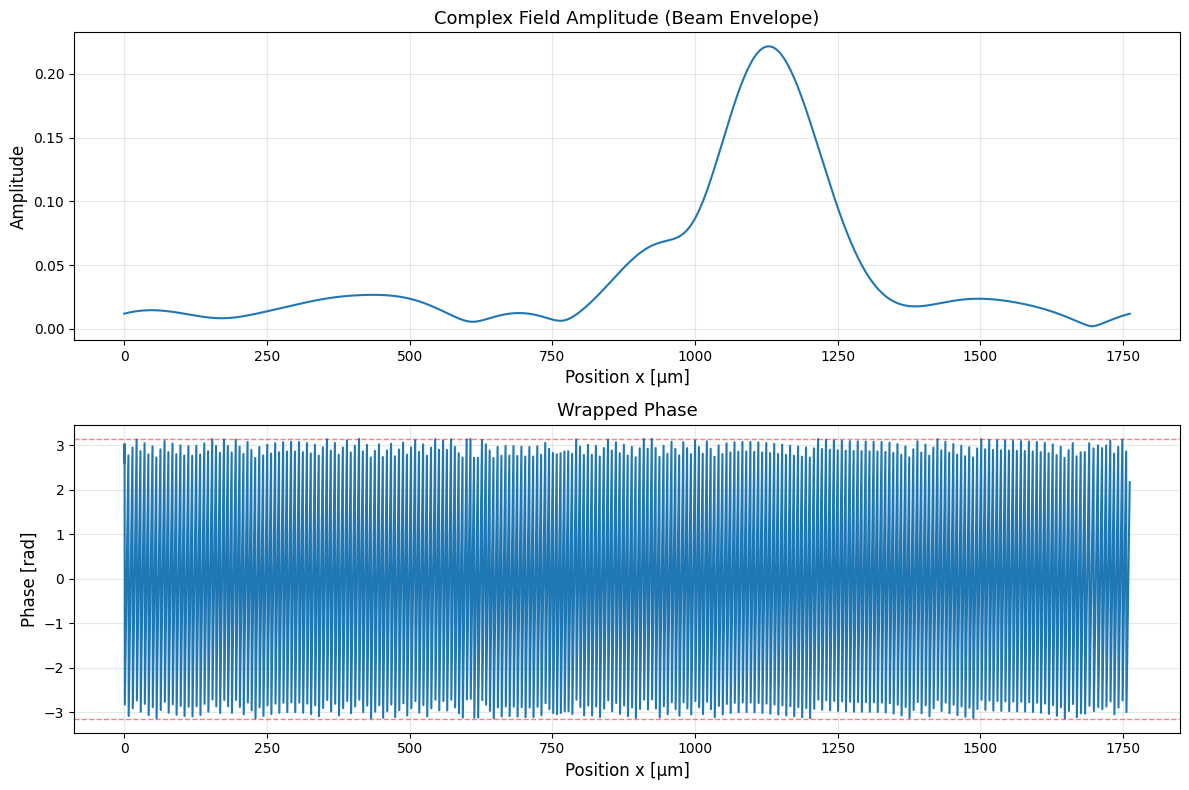

In [94]:
# Inverse FFT to get complex field
complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

# Extract amplitude and wrapped phase
amplitude = np.abs(complex_field)
phase_wrapped = np.angle(complex_field)

# Visualize complex field
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Amplitude (beam envelope)
ax = axes[0]
ax.plot(y_m*1e6, amplitude, linewidth=1.5)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title('Complex Field Amplitude (Beam Envelope)', fontsize=13)
ax.grid(True, alpha=0.3)

# Wrapped phase
ax = axes[1]
ax.plot(y_m*1e6, phase_wrapped, linewidth=1.5)
ax.axhline(np.pi, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(-np.pi, color='r', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Position x [μm]', fontsize=12)
ax.set_ylabel('Phase [rad]', fontsize=12)
ax.set_title('Wrapped Phase', fontsize=13)
ax.set_ylim(-np.pi*1.1, np.pi*1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

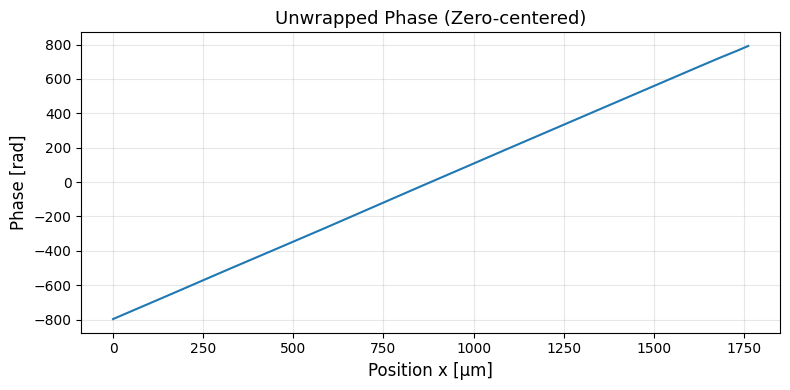

In [95]:
bend_line = line
# Standard unwrap (left-to-right) and center at x=0
phase_unwrapped = np.unwrap(phase_wrapped)

y_px = np.arange(len(bend_line))
beam_center_estimate_px = np.sum(y_px*bend_line)/np.sum(bend_line)#moment: sum of values * their position / sum of all values
phase_centered = phase_unwrapped - phase_unwrapped[M//2]
#phase_centered = phase_unwrapped - phase_unwrapped[int(beam_center_estimate_px)]

# Visualize only the unwrapped and centered phase
plt.figure(figsize=(8, 4))
plt.plot(y_m*1e6, phase_centered, linewidth=1.5)
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Phase [rad]', fontsize=12)
plt.title('Unwrapped Phase (Zero-centered)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

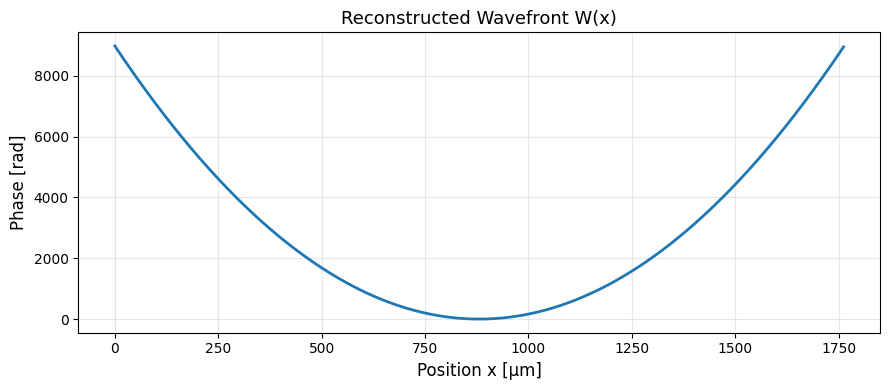

In [96]:
dy_m = y_m[1] - y_m[0]  # Spatial sampling interval [m]
# Simple cumulative integration with scaling
wavefront_temp = np.cumsum(phase_centered) * dy_m * grating_pitch_m / wavelength_m / 2

# Re-center at x=0 to remove piston term
wavefront_reconstructed = wavefront_temp - wavefront_temp[M//2]

# Plot reconstructed wavefront
plt.figure(figsize=(9, 4))
plt.plot(y_m*1e6, wavefront_reconstructed, linewidth=2)
plt.xlabel('Position x [μm]', fontsize=12)
plt.ylabel('Phase [rad]', fontsize=12)
plt.title('Reconstructed Wavefront W(x)', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



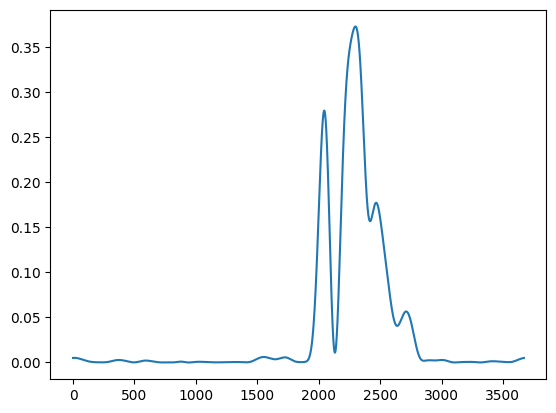

In [103]:
field = amplitude*np.exp(1j*wavefront_reconstructed)
plt.plot(np.abs(field)**2)

In [126]:
wavefront_list = []
fields_list = []
plt.figure(figsize=(9, 4))
line_colors = plt.cm.viridis(np.linspace(0, 1, len(bends_um)))
for i_b in [7]:
    line = images[i_b,1500:3000,200:220].mean(axis=1)
    line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
    freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))

    #from scipy.signal import find_peaks

    # Transform intensity pattern to frequency domain
    I_fft = line_FFT

    # Create frequency array
    freq = freq_y_cpm
    M = len(freq)
    df = freq[1]-freq[0]  # Frequency resolution [1/m]

    mask = (freq > 0.10e6) & (freq < 0.17e6)

    # Find peaks in FFT spectrum (use magnitude)
    I_fft_magnitude = np.abs(I_fft)
    # peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

    # Identify carrier frequency (should be at ±1/pitch)
    carrier_freq_ideal = 1 / grating_pitch_m
    carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
    #carrier_idx = np.argmax(I_fft_magnitude*mask)
    carrier_freq_measured = freq[carrier_idx]


    # Create Gaussian filter centered on +1 order
    filter_width = 10.0  # pixels (standard deviation)
    x_indices = np.arange(M)
    gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

    # Apply filter to FFT
    I_fft_filtered = I_fft * gaussian_filter

    # Normalize for visualization (so all curves are visible on same plot)
    I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
    I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

    # Inverse FFT to get complex field
    complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

    # Extract amplitude and wrapped phase
    amplitude = np.abs(complex_field)
    phase_wrapped = np.angle(complex_field)

    # Standard unwrap (left-to-right) and center at x=0
    phase_unwrapped = np.unwrap(phase_wrapped)
    phase_centered = phase_unwrapped - phase_unwrapped[M//2]

    dy_m = y_m[1] - y_m[0]  # Spatial sampling interval [m]
    # Simple cumulative integration with scaling
    wavefront_temp = np.cumsum(phase_centered) * dy_m * grating_pitch_m / wavelength_m / 2

    # Re-center at x=0 to remove piston term
    wavefront_reconstructed = wavefront_temp - wavefront_temp[M//2]
    wavefront_list.append(wavefront_reconstructed)
    field = amplitude*np.exp(1j*wavefront_reconstructed)
    fields_list.append(field)
    line = images[i_b,:,350:370].mean(axis=1)
    # # Plot reconstructed wavefront
    # plt.figure(figsize=(9, 4))
    plt.plot(y_m*1e6, np.abs(field)**2, linewidth=2, label = f'{bends_um[i_b]:.1f} um', color = line_colors[i_b])
    plt.plot(y_m*1e6, line/np.max(line), label = f'{bends_um[i_b]:.1f} um', color = line_colors[i_b])
    plt.xlabel('Position x [μm]', fontsize=12)
    plt.ylabel('Phase [rad]', fontsize=12)
    plt.title('Reconstructed Wavefront W(x)', fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
plt.legend()


IndexError: index 2013 is out of bounds for axis 0 with size 1500

<Figure size 900x400 with 0 Axes>

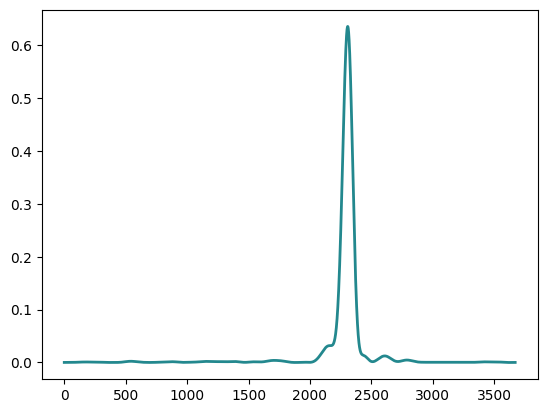

In [125]:
plt.plot(np.abs(field)**2, linewidth=2, label = f'{bends_um[i_b]:.1f} um', color = line_colors[i_b])